In [1]:
import os
import pickle
import scanpy as sc
import numpy as np
import pyranges as pr
import pandas as pd
import anndata as ad
from gtfparse import read_gtf
data_dir = '/hdd/jupyter/brad/scenicplus/motor-pathway_multiome/motor-pathway_multiome_seurat_cellbender.0.05_preprocess_cr/data/'
work_dir = '/hdd/jupyter/brad/scenicplus/motor-pathway_multiome/motor-pathway_multiome_seurat_cellbender.0.05_preprocess_cr/ra-arco-hvc-nc_astro-oligo_seurat-snrna-clustering/anndata_rna/'
tmp_dir = '/tmp/motor-pathway_multiome'
adata_fname = os.path.join(data_dir, "adata.h5ad")
adata_out_fname = os.path.join(work_dir, 'adata.h5ad')

## snRNA-seq

In [2]:
adata = sc.read_h5ad(adata_fname)

In [3]:
adata

AnnData object with n_obs × n_vars = 17334 × 15948
    obs: 'cluster', 'position', 'assignment', 'sample_short', 'run', 'replicate'
    var: 'name'
    obsm: 'X_dims30nn30mindist0.3'

In [4]:

adata_filt = adata[adata.obs.cluster.str.contains('Astro|Oligo')]
adata_filt.obs['cluster'] = adata_filt.obs['cluster'].str.extract('([A-Za-z]+)')
#cluster_counts = adata_filt.obs.cluster.value_counts()
#clusters_to_keep = cluster_counts.index[cluster_counts > 20]
#adata_filt = adata_filt[adata_filt.obs.cluster.isin(clusters_to_keep)]
#adata_filt.obs.cluster.value_counts()
adata = adata_filt


/tmp/ipykernel_2330988/439589657.py:2: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_filt.obs['cluster'] = adata_filt.obs['cluster'].str.extract('([A-Za-z]+)')


In [5]:

cluster_var = 'cluster'
cell_data = adata.obs
cell_data[cluster_var] = cell_data[cluster_var].astype(str) # set data type of the celltype column to str, otherwise the export_pseudobulk function will complain.
cell_data[cluster_var] = cell_data[cluster_var].astype(str)
cell_data[cluster_var]


AAACGCGCAGTAAAGC-1    Astro
AAATCCGGTTAGTACG-1    Astro
AAATGGCCACCTAATG-1    Astro
AACTAGCTCATAATCG-1    Oligo
AAGAACAGTGGTTCTT-1    Oligo
                      ...  
CGGATTAGTGTTCCCA-8    Astro
CTCATTGTCTGTGCAG-8    Oligo
GAACCAAAGTAAAGGT-8    Astro
GGTGCTGGTTGTTGCT-8    Astro
TACATCAAGTCTGGGC-8    Oligo
Name: cluster, Length: 1605, dtype: object

In [6]:
adata.obs[cluster_var].value_counts()

Astro    840
Oligo    765
Name: cluster, dtype: int64

In [7]:
adata.raw = adata
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
sc.pp.highly_variable_genes(adata, min_mean=0.0125, max_mean=3, min_disp=0.5)
adata = adata[:, adata.var.highly_variable]
sc.pp.scale(adata, max_value=10)

/home/brad/micromamba/envs/scenicplus/lib/python3.11/site-packages/scanpy/preprocessing/_simple.py:843: UserWarning: Revieved a view of an AnnData. Making a copy.
  view_to_actual(adata)


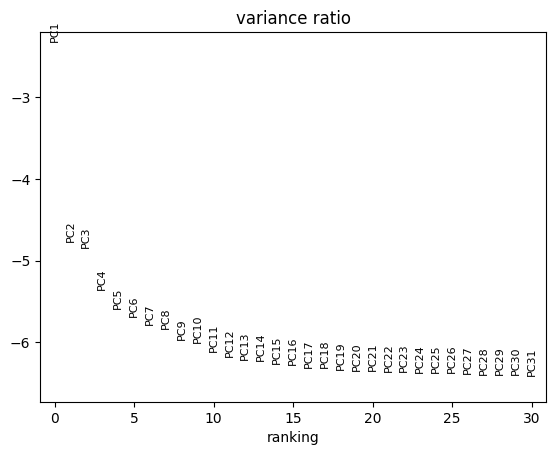

In [8]:
sc.tl.pca(adata, svd_solver='arpack')
sc.pl.pca_variance_ratio(adata, log=True)

... storing 'cluster' as categorical
/home/brad/micromamba/envs/scenicplus/lib/python3.11/site-packages/scanpy/plotting/_dotplot.py:749: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)


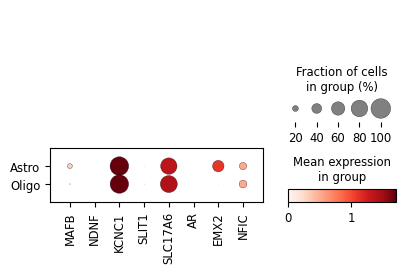

In [9]:
sc.pl.dotplot(adata, var_names=['MAFB', 'NDNF', 'KCNC1', 'SLIT1', 'SLC17A6','AR', 'EMX2', 'NFIC'], groupby=cluster_var)

/home/brad/micromamba/envs/scenicplus/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:378: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/home/brad/micromamba/envs/scenicplus/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:378: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


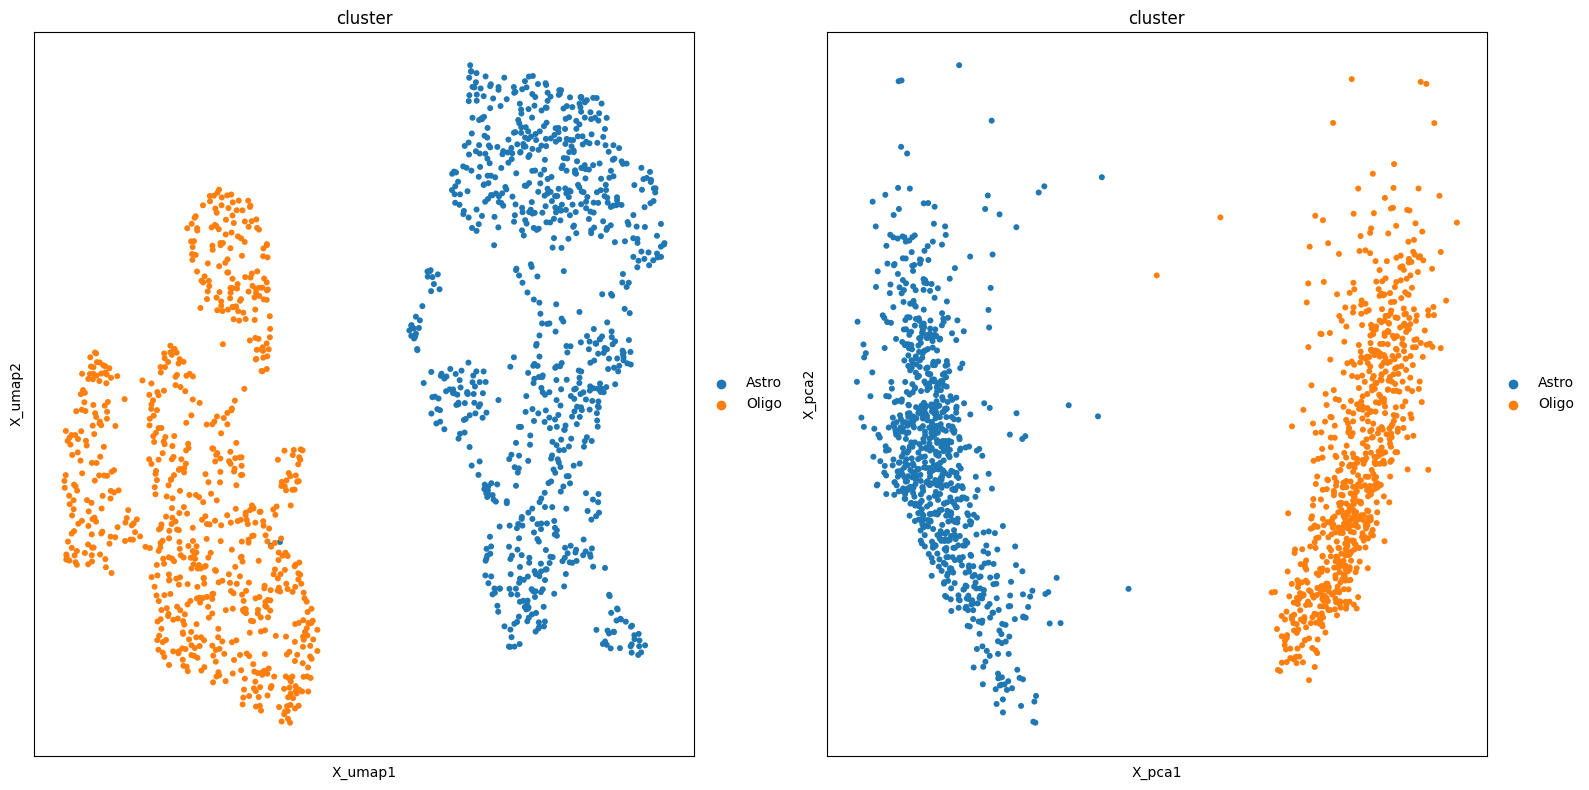

In [10]:
import matplotlib.pyplot as plt

sc.pp.neighbors(adata, n_neighbors=10, n_pcs=10)
sc.tl.umap(adata)

fig, axs = plt.subplots(ncols = 2, figsize = (16,8))
sc.pl.embedding(adata, basis='X_umap', ax=axs[0], color = cluster_var, show=False)
sc.pl.embedding(adata, basis='X_pca', ax=axs[1], color = cluster_var, show=False)
fig.tight_layout()
plt.show()

/home/brad/micromamba/envs/scenicplus/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:378: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


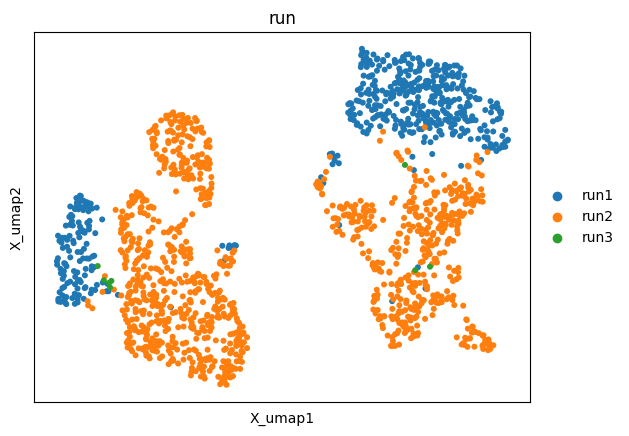

In [11]:
sc.pl.embedding(adata, basis='X_umap', color = 'run', show=True)

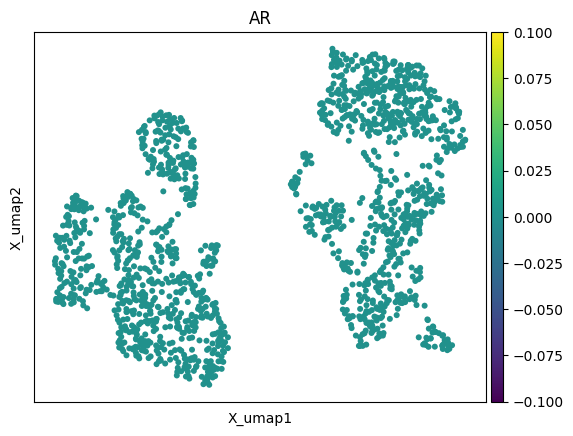

In [12]:
sc.pl.embedding(adata, basis='X_umap', color = 'AR', show=True)

In [13]:
### Fix cell_data cell name to match cisTopic object
cell_data_mod = adata.obs.copy()
cell_data_mod.index = cell_data_mod.index.str.replace("-[0-9]", "-1", regex=True)
indices = cell_data_mod.index.to_list()
cell_data_mod["barcode"] = cell_data_mod.index
out = cell_data_mod.apply(lambda x: '___'.join([x.barcode, f"{x.sample_short}"]), axis=1)
cell_data_mod.index = out
adata.obs = cell_data_mod
print(adata.obs)

                               cluster position assignment sample_short   run  \
AAACGCGCAGTAAAGC-1___hvc_run1    Astro      hvc          2     hvc_run1  run1   
AAATCCGGTTAGTACG-1___hvc_run1    Astro      hvc          2     hvc_run1  run1   
AAATGGCCACCTAATG-1___hvc_run1    Astro      hvc          2     hvc_run1  run1   
AACTAGCTCATAATCG-1___hvc_run1    Oligo      hvc          1     hvc_run1  run1   
AAGAACAGTGGTTCTT-1___hvc_run1    Oligo      hvc          2     hvc_run1  run1   
...                                ...      ...        ...          ...   ...   
CGGATTAGTGTTCCCA-1___arco_run3   Astro     arco          2    arco_run3  run3   
CTCATTGTCTGTGCAG-1___arco_run3   Oligo     arco          1    arco_run3  run3   
GAACCAAAGTAAAGGT-1___arco_run3   Astro     arco          3    arco_run3  run3   
GGTGCTGGTTGTTGCT-1___arco_run3   Astro     arco          1    arco_run3  run3   
TACATCAAGTCTGGGC-1___arco_run3   Oligo     arco          1    arco_run3  run3   

                           

In [14]:
adata.write_h5ad(adata_out_fname)

... storing 'barcode' as categorical
